In [2]:
# ============================================================================
# CELL 1: IMPORTS AND CONFIGURATION
# ============================================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_absolute_error

# Deep Learning Framework: TensorFlow & Keras
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Configuration
DATASET_PATH = Path("/content/drive/MyDrive/Datasets/Nutrition5k/nutrition5k_dataset")
METADATA_PATH = DATASET_PATH / "metadata"
IMAGERY_PATH = DATASET_PATH / "imagery" / "realsense_overhead"

# Constants
IMG_SIZE = 224  # Standard for EfficientNetB0
BATCH_SIZE = 32
RANDOM_SEED = 42
EPOCHS = 20

# Set Seeds for Reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    tf.random.set_seed(seed)
    random.seed(seed)

set_seed(RANDOM_SEED)

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU')) > 0}")

Mounted at /content/drive
TensorFlow Version: 2.19.0
GPU Available: False


In [3]:
# ============================================================================
# CELL 2: DATA PREPROCESSING & CLEANING
# ============================================================================

def load_and_clean_metadata():
    print("Loading metadata...")

    # COMPREHENSIVE IGNORE LIST: Invisible ingredients & condiments
    ignore_list = {
        'salt', 'pepper', 'olive oil', 'vegetable oil', 'sugar', 'brown sugar',
        'vinegar', 'soy sauce', 'lemon juice', 'orange juice', 'grapefruit juice',
        'mayonnaise', 'butter', 'ketchup', 'mustard', 'syrup', 'white wine', 'wine',
        'cream', 'sour cream', 'buttermilk', 'milk', 'flour', 'caesar dressing',
        'vinaigrette', 'salsa', 'pesto', 'plate only', 'deprecated', 'water',
        'lemon', 'lime', 'honey', 'maple syrup', 'balsamic vinegar', 'oil',
        'spray', 'dressing'
    }

    data = []

    # Process both Cafe1 and Cafe2 files
    files = [METADATA_PATH / "dish_metadata_cafe1.csv",
             METADATA_PATH / "dish_metadata_cafe2.csv"]

    for file_path in files:
        if not file_path.exists():
            print(f"Warning: {file_path.name} not found.")
            continue

        # FIX FOR PARSER ERROR:
        # The file has variable length rows (ragged). We explicitly define column names
        # (0 to 399) to force pandas to read all columns without crashing.
        try:
            df_raw = pd.read_csv(file_path, header=None, names=[i for i in range(400)], engine='python')
        except Exception as e:
            print(f"Error reading {file_path.name}: {e}")
            continue

        for _, row in df_raw.iterrows():
            dish_id = str(row[0])

            # --- UPDATED NUTRITION VECTOR (NO MASS) ---
            # row[1]=Cal, row[2]=Mass(SKIP), row[3]=Fat, row[4]=Carb, row[5]=Protein
            nutrition_values = [
                float(row[1]) if pd.notna(row[1]) else 0.0, # Calories
                # Skipped row[2] (Mass) - [cite: 41]
                float(row[3]) if pd.notna(row[3]) else 0.0, # Fat
                float(row[4]) if pd.notna(row[4]) else 0.0, # Carb
                float(row[5]) if pd.notna(row[5]) else 0.0  # Protein
            ]

            # FILTER 1: Skip incomplete/testing data (0 calories)
            if nutrition_values[0] <= 1.0: continue

            # Parse ingredients
            visible_ingredients = []
            # Ingredients start at col 6, stepping by 7
            for i in range(6, len(row), 7):
                if i+1 >= len(row): break
                ing = row[i+1]

                # Check if ingredient exists and is NOT in the ignore list
                if pd.notna(ing):
                    clean_ing = str(ing).strip().lower()
                    if clean_ing not in ignore_list and len(clean_ing) > 1:
                        visible_ingredients.append(clean_ing)

            # FILTER 2: Skip dishes that have 0 visible ingredients
            if not visible_ingredients: continue

            # FILTER 3: Verify image exists
            img_path = IMAGERY_PATH / dish_id / "rgb.png"
            if not img_path.exists(): continue

            data.append({
                'dish_id': dish_id,
                'path': str(img_path),
                'nutrition': nutrition_values, # Vector of 4 values
                'ingredients': visible_ingredients
            })

    df = pd.DataFrame(data)
    print(f"✓ Data Cleaning Complete. Valid samples: {len(df)}")
    return df

df = load_and_clean_metadata()

# Prepare Labels (Multi-Label Binarizer)
mlb = MultiLabelBinarizer()
binary_labels = mlb.fit_transform(df['ingredients'])
num_classes = len(mlb.classes_)

print(f"Unique Visible Ingredients: {num_classes}")
print("Sample Nutrition Vector (Cal, Fat, Carb, Prot):", df.iloc[0]['nutrition'])

Loading metadata...
✓ Data Cleaning Complete. Valid samples: 3241
Unique Visible Ingredients: 168
Sample Nutrition Vector (Cal, Fat, Carb, Prot): [300.794281, 12.387489, 28.21829, 18.63397]


In [4]:
# ============================================================================
# CELL 3: DATA SPLITTING & TF DATASET PIPELINE
# ============================================================================

# Split Data: Train (70%), Val (15%), Test (15%) [cite: 69]
train_df, test_df, train_labels, test_labels = train_test_split(
    df, binary_labels, test_size=0.3, random_state=RANDOM_SEED
)
val_df, test_df, val_labels, test_labels = train_test_split(
    test_df, test_labels, test_size=0.5, random_state=RANDOM_SEED
)

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Image Parsing Function
def process_path(path, ingredients_target, nutrition_target):
    # Load Image [cite: 216]
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE]) # Resize [cite: 58]
    img = tf.cast(img, tf.float32)

    # Return inputs and dictionary of outputs
    return img, {
        'ingredients_output': ingredients_target,
        'nutrition_output': nutrition_target
    }

# Augmentation Layer (Applied inside dataset pipeline) [cite: 64]
augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2),
])

def make_dataset(dataframe, labels, is_train=False):
    paths = dataframe['path'].values

    # Stack nutrition lists into a proper Numpy Matrix (N, 4)
    nutrition_stack = np.vstack(dataframe['nutrition'].values).astype(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels, nutrition_stack))

    # Map raw paths to images
    ds = ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)

    if is_train:
        # Apply augmentation only to training set
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                   num_parallel_calls=tf.data.AUTOTUNE)
        ds = ds.shuffle(buffer_size=1000)

    # Batch and Prefetch
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, train_labels, is_train=True)
val_ds = make_dataset(val_df, val_labels)
test_ds = make_dataset(test_df, test_labels)

print("✓ Data pipeline ready: Predicts Ingredients + 4 Nutrition Values")

Train: 2268, Val: 486, Test: 487
✓ Data pipeline ready: Predicts Ingredients + 4 Nutrition Values


In [5]:
# ============================================================================
# CELL 4: MODEL ARCHITECTURE (EfficientNet Multi-Task)
# ============================================================================

def build_model():
    # Backbone: EfficientNetB0 (As per PDF Section 6.2)
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    base_model.trainable = True # Fine-tuning

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = tf.keras.applications.efficientnet.preprocess_input(inputs)
    x = base_model(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)

    # --- HEAD 1: Ingredients ---
    ingredients_output = layers.Dense(num_classes, activation='sigmoid', name='ingredients_output')(x)

    # --- HEAD 2: Nutrition (Regression) ---
    # Output size is 4: [Calories, Fat, Carb, Protein]
    nutrition_output = layers.Dense(4, activation='linear', name='nutrition_output')(x)

    model = tf.keras.Model(inputs=inputs, outputs=[ingredients_output, nutrition_output])
    return model

model = build_model()
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ efficientnetb0      │ (None, 7, 7,      │  4,049,571 │ input_layer_2[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ efficientnetb0[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1280)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ingredients_output  │ (None, 168)       │    215,208 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ nutrition_output    │ (None, 4)         │      5,124 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,269,903 (16.29 MB)

 Trainable params: 4,227,880 (16.13 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [9]:
# ============================================================================
# CELL 5: MODEL TRAINING
# ============================================================================

# Loss Functions
losses = {
    'ingredients_output': 'binary_crossentropy',
    'nutrition_output': 'mean_absolute_error'
}

# Loss Weights
loss_weights = {'ingredients_output': 1.0, 'nutrition_output': 0.01}

# Compilation
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=losses,
    loss_weights=loss_weights,
    metrics={
        'ingredients_output': 'binary_accuracy',
        'nutrition_output': 'mae'
    }
)

# Callbacks
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    callbacks.ModelCheckpoint('best_food_model.keras', save_best_only=True, monitor='val_loss')
]

print("Starting training...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks_list,
    verbose=1
)
print("✓ Training Complete")

Starting training...
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1021s 12s/step - ingredients_output_binary_accuracy: 0.7278 - ingredients_output_loss: 0.5631 - loss: 1.3081 - nutrition_output_loss: 74.5053 - nutrition_output_mae: 74.5057 - val_ingredients_output_binary_accuracy: 0.9676 - val_ingredients_output_loss: 0.2188 - val_loss: 0.9593 - val_nutrition_output_loss: 76.4286 - val_nutrition_output_mae: 74.9792
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 808s 11s/step - ingredients_output_binary_accuracy: 0.9675 - ingredients_output_loss: 0.1688 - loss: 0.9231 - nutrition_output_loss: 75.4260 - nutrition_output_mae: 75.4260 - val_ingredients_output_binary_accuracy: 0.9676 - val_ingredients_output_loss: 0.1729 - val_loss: 0.9036 - val_nutrition_output_loss: 75.1031 - val_nutrition_output_mae: 73.6458
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 819s 11s/step - ingredients_output_binary_accuracy: 0.9683 - ingredients_output_loss: 0.1232 - loss: 0.8235 - nutrition_output_loss: 70.0312 - nutrition_output_

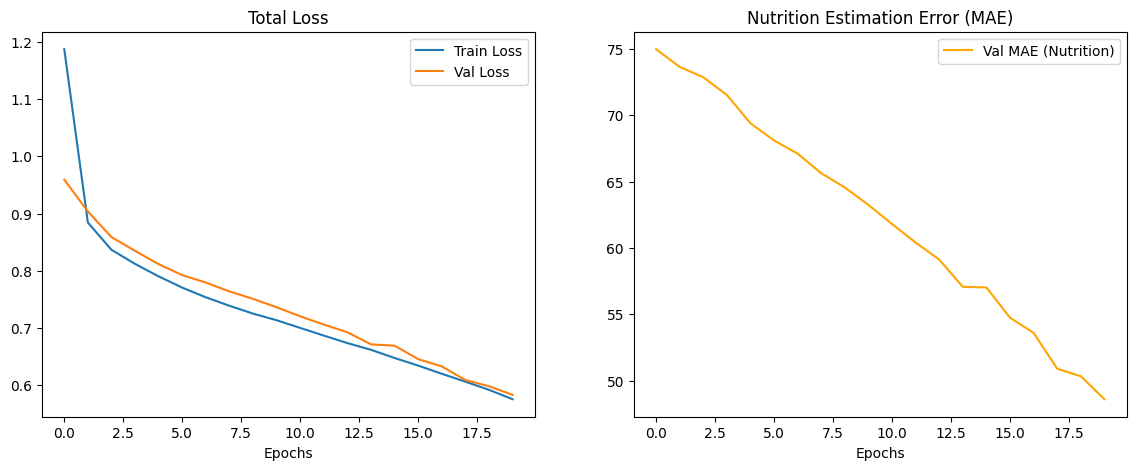


SAMPLE PREDICTION (Ingredients + Nutrition)
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


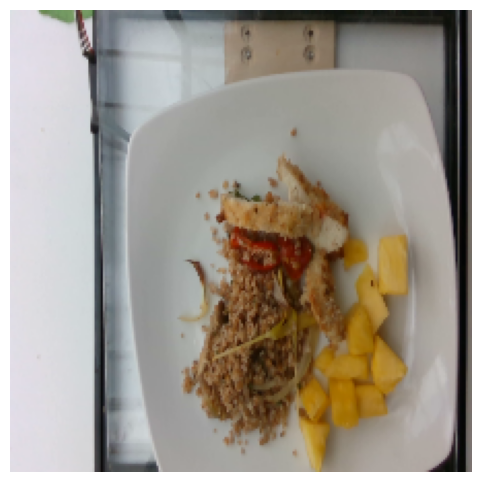

Recognized Ingredients: garlic, onions, parsley, arugula, thyme
-----------------------------------------------------------------
Nutrient     | Actual       | Predicted    | Diff        
-----------------------------------------------------------------
Calories     | 197.3        | 122.8        | 74.5        
Fat (g)      | 4.8          | 17.7         | 12.9        
Carbs (g)    | 18.1         | 20.1         | 2.0         
Protein (g)  | 20.0         | 26.7         | 6.7         
-----------------------------------------------------------------


In [10]:
# ============================================================================
# CELL 6: EVALUATION & PREDICTION VISUALIZATION
# ============================================================================

def plot_history(history):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Total Loss
    ax[0].plot(history.history['loss'], label='Train Loss')
    ax[0].plot(history.history['val_loss'], label='Val Loss')
    ax[0].set_title('Total Loss')
    ax[0].set_xlabel('Epochs')
    ax[0].legend()

    # Plot Nutrition MAE
    ax[1].plot(history.history['val_nutrition_output_mae'], label='Val MAE (Nutrition)', color='orange')
    ax[1].set_title('Nutrition Estimation Error (MAE)')
    ax[1].set_xlabel('Epochs')
    ax[1].legend()
    plt.show()

plot_history(history)

print("\n" + "="*50)
print("SAMPLE PREDICTION (Ingredients + Nutrition)")
print("="*50)

# Grab a random test batch
for imgs, labels in test_ds.take(1):
    # Predict
    preds = model.predict(imgs)
    pred_ing = preds[0]  # Ingredients Probabilities
    pred_nut = preds[1]  # Nutrition Vector [4]

    # Display the first image in the batch
    plt.figure(figsize=(6,6))
    plt.imshow(imgs[0].numpy().astype("uint8"))
    plt.axis('off')
    plt.show()

    # 1. Decode Ingredients
    top_indices = pred_ing[0].argsort()[-5:][::-1]
    detected_food = [mlb.classes_[i] for i in top_indices]

    # 2. Decode Nutrition
    # Actual Labels: [Calories, Fat, Carb, Protein]
    actual_nut = labels['nutrition_output'][0].numpy()
    predicted_nut = pred_nut[0]

    print(f"Recognized Ingredients: {', '.join(detected_food)}")
    print("-" * 65)
    print(f"{'Nutrient':<12} | {'Actual':<12} | {'Predicted':<12} | {'Diff':<12}")
    print("-" * 65)

    # Only 4 nutrients now (No Mass)
    nutrients = ['Calories', 'Fat (g)', 'Carbs (g)', 'Protein (g)']

    for i, nutrient in enumerate(nutrients):
        act = actual_nut[i]
        pre = predicted_nut[i]
        diff = abs(act - pre)
        print(f"{nutrient:<12} | {act:<12.1f} | {pre:<12.1f} | {diff:<12.1f}")

    print("-" * 65)
    break

In [6]:
import json

# Get the list of ingredients from your MultiLabelBinarizer
ingredient_classes = list(mlb.classes_)

# Save to a file
with open('ingredients.json', 'w') as f:
    json.dump(ingredient_classes, f)

print("✓ ingredients.json saved! Download this file and put it with app.py")

✓ ingredients.json saved! Download this file and put it with app.py
